In [ ]:
import pandas as pd
import seaborn as sns
import yaml
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [5]:
demo_df = pd.read_csv(config["input_data"]["file1"])
demo_df


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [4]:
demo_df.shape

(70609, 9)

In [5]:
demo_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


In [6]:
print(demo_df.dtypes)

client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                   str
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object


In [10]:
sorted_balance = demo_df.sort_values(by='bal')
sorted_balance

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
57006,9020160,9.0,108.0,63.0,F,1.0,13789.42,2.0,2.0
55126,989035,15.0,184.0,41.0,M,2.0,13791.34,1.0,1.0
61826,3280109,15.0,185.0,59.0,F,2.0,13791.80,7.0,7.0
66292,9862353,17.0,205.0,59.0,M,2.0,13792.98,7.0,7.0
53141,2210130,8.0,105.0,18.0,M,2.0,13793.69,3.0,3.0
...,...,...,...,...,...,...,...,...,...
46076,8611797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47189,5144725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49846,1037867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63701,1618749,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There are a some rows without any data except a client ID. They are unusable so let's drop them

In [11]:
demo_df_cleaned = demo_df.dropna(how='all', subset=demo_df.columns.difference(['client_id']))
demo_df_cleaned = demo_df_cleaned.reset_index(drop=True)
demo_df_cleaned

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70590,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70591,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70592,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70593,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [ ]:
#save cleaned data file
demo_df_cleaned.to_csv('demo_df_cleaned.csv', index=False)

In [7]:
demo_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 70595 entries, 0 to 70594
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70595 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


Only 1 NaN value left in age column. We will ignore this Nan value since it will not distort our research

In [8]:
#check how many time clients logged on in the last 6 months
sorted_unique_values = sorted(demo_df_cleaned['logons_6_mnth'].unique())

print(sorted_unique_values)


[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


In [9]:
# Create a Boolean series to filter users with 9 logons
top_users_filter = demo_df_cleaned['logons_6_mnth'] == 9

# Filter the DataFrame using the Boolean series
top_users = demo_df_cleaned[top_users_filter]

# Display the first few rows of the filtered result
display(top_users)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0
11,2537139,8.0,99.0,51.5,U,2.0,135940.68,6.0,9.0
...,...,...,...,...,...,...,...,...,...
50473,3823121,14.0,178.0,68.5,F,2.0,32666.22,6.0,9.0
50477,6751438,8.0,98.0,49.5,U,2.0,416988.75,6.0,9.0
50481,9932367,23.0,280.0,57.0,F,2.0,94466.55,6.0,9.0
50483,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0


There are 12.350 clients how logged on 9 times in the last 6 months

In [10]:
#sort clients by ages
top_users_age = top_users.sort_values(by= 'clnt_age')
display(top_users_age)


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
2716,6516140,5.0,66.0,17.5,U,2.0,74939.63,6.0,9.0
23120,8927242,3.0,39.0,17.5,U,3.0,56048.17,6.0,9.0
22034,8365990,3.0,40.0,17.5,U,2.0,66353.04,6.0,9.0
2283,5269888,20.0,243.0,17.5,F,2.0,39631.34,6.0,9.0
3195,5747508,5.0,66.0,17.5,U,2.0,42447.47,6.0,9.0
...,...,...,...,...,...,...,...,...,...
45342,1359640,12.0,148.0,92.0,M,2.0,596701.54,6.0,9.0
33047,6533602,29.0,348.0,93.0,F,2.0,362103.22,6.0,9.0
42551,3112487,7.0,91.0,93.0,U,2.0,30461.89,6.0,9.0
35861,5890936,28.0,347.0,93.5,M,3.0,1364856.21,6.0,9.0


In [11]:
# Group by 'clnt_age' and count the number of occurrences
age_distribution = top_users_age.groupby('clnt_age').size().reset_index(name='client_count')

# Sort the resulting DataFrame by 'clnt_age' for readability
age_distribution_sorted = age_distribution.sort_values(by='clnt_age')

# Display the DataFrame showing the number of clients of each age
display(age_distribution_sorted)

,clnt_age,client_count
0,17.5,5
1,18.0,11
2,18.5,20
3,19.0,11
4,19.5,24
...,...,...
145,91.5,1
146,92.0,1
147,93.0,2
148,93.5,1


In [12]:
# Calculate the mean age
mean_age = top_users_age['clnt_age'].mean()
print(f"Mean age: {mean_age}")

# Calculate the median age
median_age = top_users_age['clnt_age'].median()
print(f"Median age: {median_age}")

# Calculate the mode(s) of the ages using dropna() to ensure accuracy
mode_age = top_users_age['clnt_age'].dropna().mode()
print(f"Mode age(s): {mode_age.tolist()}")

percentiles = top_users_age['clnt_age'].quantile([0.25, 0.50, 0.75])
print(percentiles)

Mean age: 47.491133603238865
Median age: 48.0
Mode age(s): [27.5]
0.25    32.5
0.50    48.0
0.75    61.0
Name: clnt_age, dtype: float64


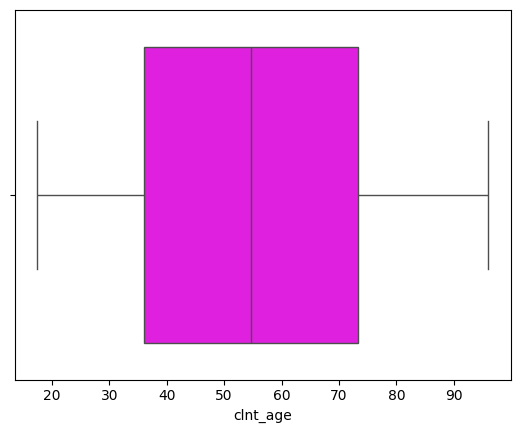

In [25]:
sns.boxplot(x = age_distribution['clnt_age'], color="fuchsia");

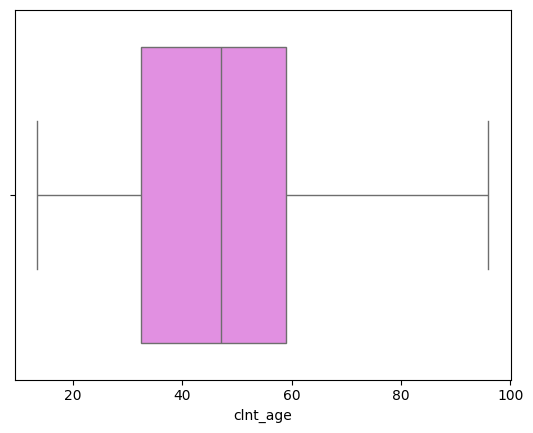

In [31]:
sns.boxplot(x = demo_df_cleaned['clnt_age'], color="violet");

In [13]:
demo_df_cleaned.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='str')

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_6104\3249746184.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo_df_cleaned, x='age_group', y='logons_6_mnth', palette="pastel")


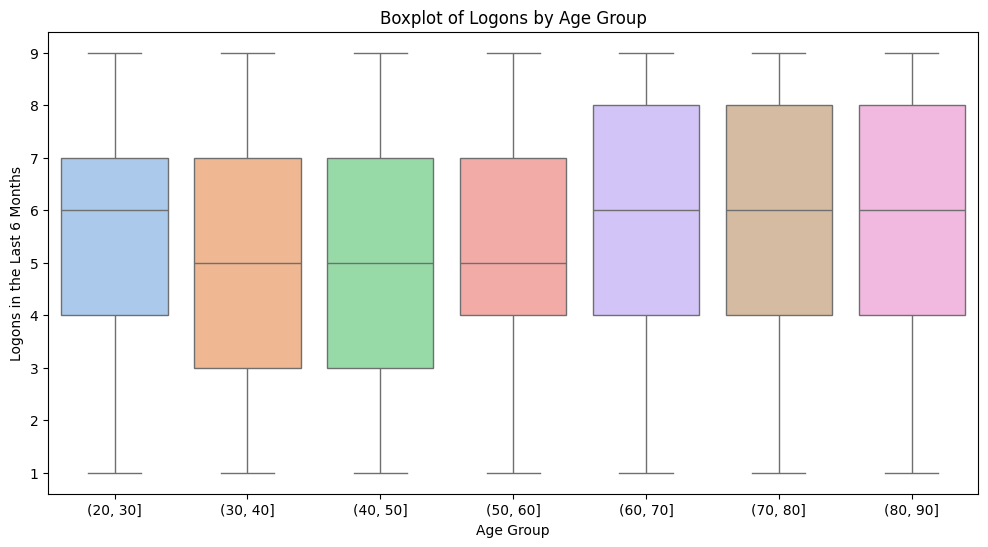

In [14]:
#Categorize ages into bins
demo_df_cleaned['age_group'] = pd.cut(demo_df_cleaned['clnt_age'], bins=range(20, 100, 10))

# Create the boxplot with age groups
plt.figure(figsize=(12, 6))
sns.boxplot(data=demo_df_cleaned, x='age_group', y='logons_6_mnth', palette="pastel")

# Add labels and title
plt.title('Boxplot of Logons by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Logons in the Last 6 Months')

# Display the plot
plt.show()

In [17]:

# Filter clients with zero logons and zero calls in the last 6 months
clients_with_no_activity = demo_df_cleaned[(demo_df_cleaned['logons_6_mnth'] == 0) & (demo_df_cleaned['calls_6_mnth'] == 0)]

# Extract ages and tenure years
selected_info = clients_with_no_activity[['clnt_age', 'clnt_tenure_yr']]

# Display the selected information
print("Ages and Tenure Years of Clients with Zero Activity:")
print(selected_info)

Ages and Tenure Years of Clients with Zero Activity:
Empty DataFrame
Columns: [clnt_age, clnt_tenure_yr]
Index: []


There are no clients that did not interact with the back via call or logon.

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_23308\2785609493.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo_df_cleaned, x='age_group', y='calls_6_mnth', palette="bright")


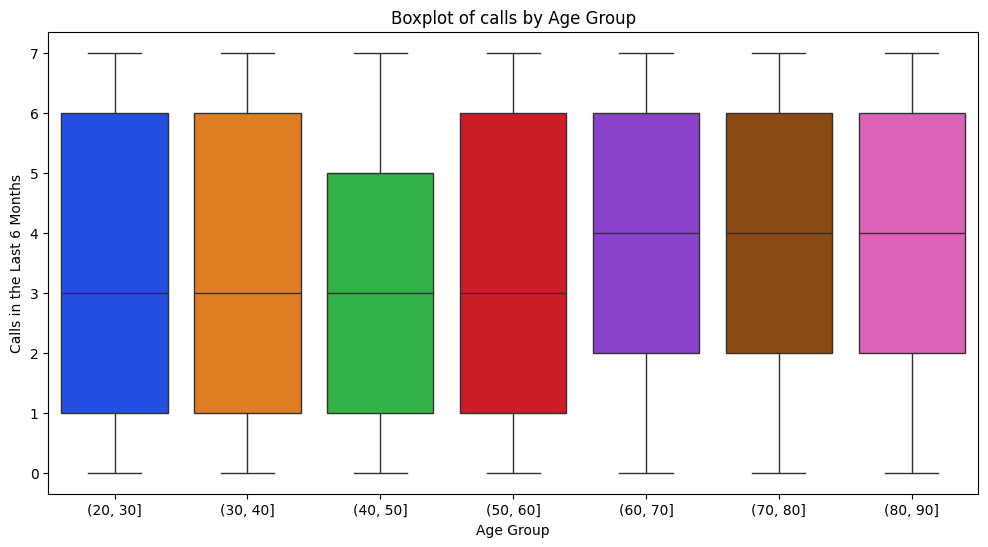

In [13]:
#Categorize ages into bins
demo_df_cleaned['age_group'] = pd.cut(demo_df_cleaned['clnt_age'], bins=range(20, 100, 10))

# Create the boxplot with age groups
plt.figure(figsize=(12, 6))
sns.boxplot(data=demo_df_cleaned, x='age_group', y='calls_6_mnth', palette="bright")

# Add labels and title
plt.title('Boxplot of calls by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Calls in the Last 6 Months')

# Display the plot
plt.show()

Clients between  are using the online log in between 48 and 61 most.
Everyone is also still using the phone with most clients calling 3 or 4 times in 6 months.

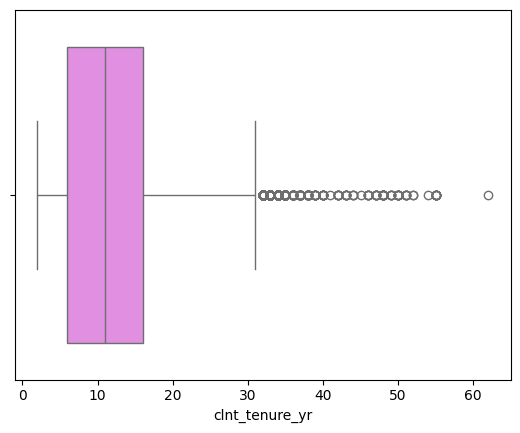

In [9]:
sns.boxplot(x = demo_df_cleaned['clnt_tenure_yr'], color="violet");

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_23308\2707144028.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo_df_cleaned, x='tenure_group', y='logons_6_mnth', palette="pastel")


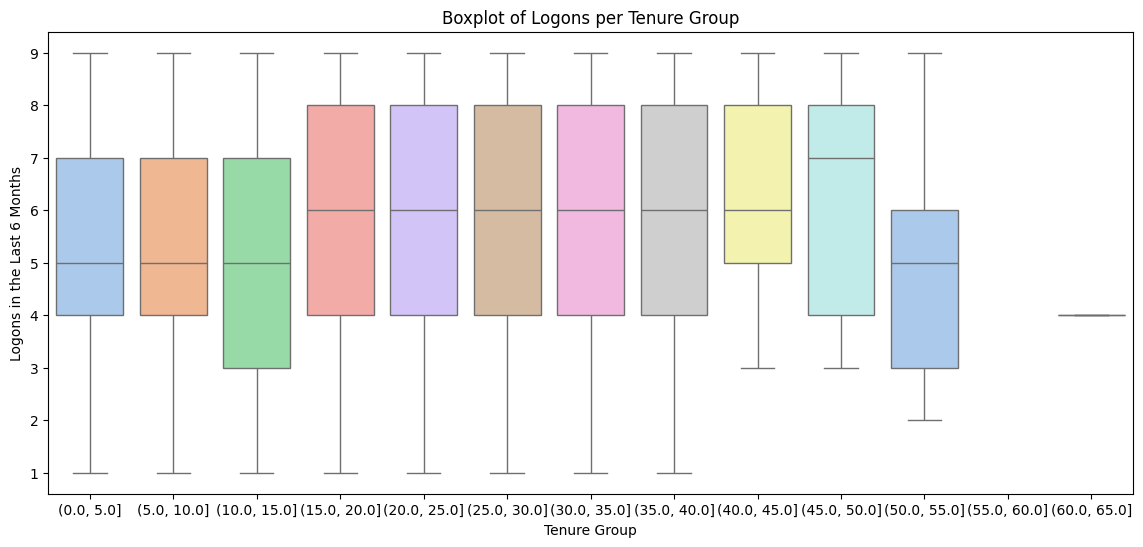

In [11]:
# Checking max for consistent binning, rounding up ensures integer bin boundaries
max_tenure_numeric = np.ceil(demo_df_cleaned['clnt_tenure_yr'].max())

# Adjust bin edges for integer demarcation using float
bin_edges = np.arange(0, max_tenure_numeric + 5, 5)  # Intervals of 5, adjusted automatically

# Categorize ages into bins
demo_df_cleaned['tenure_group'] = pd.cut(demo_df_cleaned['clnt_tenure_yr'], bins=bin_edges)

# Create the boxplot with tenure groups
plt.figure(figsize=(14, 6))
sns.boxplot(data=demo_df_cleaned, x='tenure_group', y='logons_6_mnth', palette="pastel")

# Add labels and title
plt.title('Boxplot of Logons per Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Logons in the Last 6 Months')

# Display the plot
plt.show()

C:\Users\Ready2Use\AppData\Local\Temp\ipykernel_23308\1207284917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo_df_cleaned, x='tenure_group', y='calls_6_mnth', palette="bright")


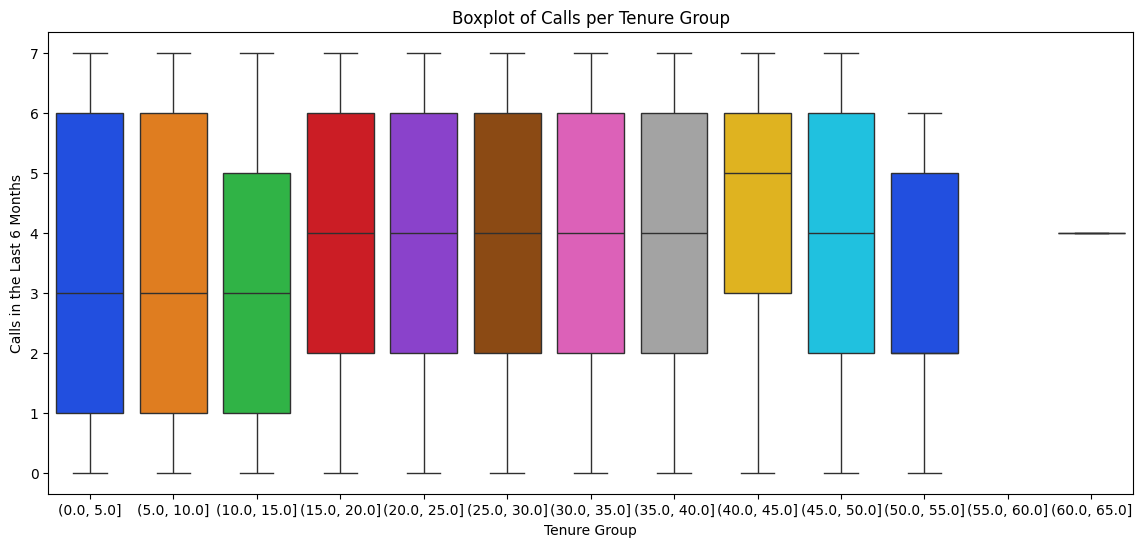

In [14]:
# Checking max for consistent binning, rounding up ensures integer bin boundaries
max_tenure_numeric = np.ceil(demo_df_cleaned['clnt_tenure_yr'].max())

# Adjust bin edges for integer demarcation using float
bin_edges = np.arange(0, max_tenure_numeric + 5, 5)  # Intervals of 5, adjusted automatically

# Categorize ages into bins
demo_df_cleaned['tenure_group'] = pd.cut(demo_df_cleaned['clnt_tenure_yr'], bins=bin_edges)

# Create the boxplot with tenure groups
plt.figure(figsize=(14, 6))
sns.boxplot(data=demo_df_cleaned, x='tenure_group', y='calls_6_mnth', palette="bright")

# Add labels and title
plt.title('Boxplot of Calls per Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Calls in the Last 6 Months')

# Display the plot
plt.show()

In [8]:
expi_df = pd.read_csv(config["output_data"]["file2"])
expi_df

,client_id,Variation
0,9988021,test
1,8320017,test
2,4033851,control
3,1982004,test
4,9294070,control
...,...,...
50495,393005,control
50496,2908510,control
50497,7230446,test
50498,5230357,test


To find out which clients belong to the test group we will join the data with the test and control groups to the demo data

In [23]:
joined_demo_expi_df = pd.merge(demo_df_cleaned, expi_df, on= 'client_id')
display(joined_demo_expi_df)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,control
...,...,...,...,...,...,...,...,...,...,...
50483,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,test
50484,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,control
50485,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,test
50486,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,test


In [24]:
joined_demo_expi_df.columns = joined_demo_expi_df.columns.str.lower()
display(joined_demo_expi_df)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,control
...,...,...,...,...,...,...,...,...,...,...
50483,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,test
50484,6967120,21.0,260.0,68.5,M,3.0,4279873.38,6.0,9.0,control
50485,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,test
50486,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,test


In [25]:
#save joined data file
joined_demo_expi_df.to_csv('joined_demo_expi_df.csv', index=False)

In [28]:
#split the group to test group and control group
# Split the DataFrame into 'test' and 'control' variations
test_group_df = joined_demo_expi_df[joined_demo_expi_df['variation'] == 'test']
control_group_df = joined_demo_expi_df[joined_demo_expi_df['variation'] == 'control']

# Display the test and control DataFrames
print("Test DataFrame:")
display(test_df)
print("\nControl DataFrame:")
display(control_df)

Test DataFrame:


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,test
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,test
7,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,test
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,test
...,...,...,...,...,...,...,...,...,...,...
50480,501496,23.0,281.0,35.0,F,2.0,32529.34,0.0,3.0,test
50483,1780858,21.0,262.0,68.5,M,3.0,372100.59,6.0,9.0,test
50485,5826160,20.0,249.0,56.5,F,2.0,44837.16,2.0,5.0,test
50486,8739285,19.0,229.0,69.5,F,2.0,44994.24,1.0,4.0,test



Control DataFrame:


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,control
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,control
5,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0,control
6,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0,control
8,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,control
...,...,...,...,...,...,...,...,...,...,...
50474,6662941,7.0,84.0,36.0,F,2.0,83101.84,4.0,7.0,control
50479,2787512,23.0,283.0,48.0,F,3.0,123618.60,1.0,4.0,control
50481,9932367,23.0,280.0,57.0,F,2.0,94466.55,6.0,9.0,control
50482,4079649,23.0,276.0,62.5,M,3.0,57575.28,4.0,7.0,control


There are 26961 clients in the test group and 23527 clients in the control group

In [29]:
#save test and control file
test_group_df.to_csv('test_group_df.csv', index=False)

In [30]:
control_group_df.to_csv('control_group_df.csv', index=False)